# W04A · 오토인코더: 압축과 복원 관찰실
2026-09-21 월요일 · 4주차 1차시 · 주교재 3.1

W03B 완료 여부와 관계없이 새 Colab 사본을 Drive에 저장하고 첫 셀부터 실행합니다.
CPU 기본, 데이터 자동 다운로드 약 11.6 MB, API 키·개인 파일 업로드 불필요.
패키지 **0.1.5**, 고정 태그 **2026-fall-w04a**. 최초 패키지 설치량은 환경에 따라 다릅니다.
이미 import한 패키지를 교체했다면 런타임을 재시작하고 처음부터 실행합니다.
[강의노트](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/course/notion/w04a/w04a-autoencoders.md)
· [기록지](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/course/notion/w04a/w04a-workbook.md)

빈칸 활동의 변수는 기본 실험과 분리되어 있습니다. 미완성 문제 때문에 다음 셀을 막지 않습니다.


In [ ]:
import sys, subprocess
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
PUBLIC_REF = '2026-fall-w04a'
try:
    ready = version('luna-genai') == '0.1.5' and version('gradio') == '6.26.0'
except PackageNotFoundError:
    ready = False
if not ready:
    if any(name in sys.modules for name in ('luna_genai', 'torch', 'gradio')):
        raise RuntimeError('패키지를 바꾸기 전에 런타임을 재시작하고 첫 셀부터 실행하세요.')
    package = str(Path('src').resolve()) if Path('src/pyproject.toml').exists() else f'git+https://github.com/lunalab-ai/genAI.git@{PUBLIC_REF}#subdirectory=src'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)
print('Python', sys.version.split()[0], 'luna-genai', version('luna-genai'), 'torch', version('torch'))


## 1. 입력이 자신의 정답이 된다
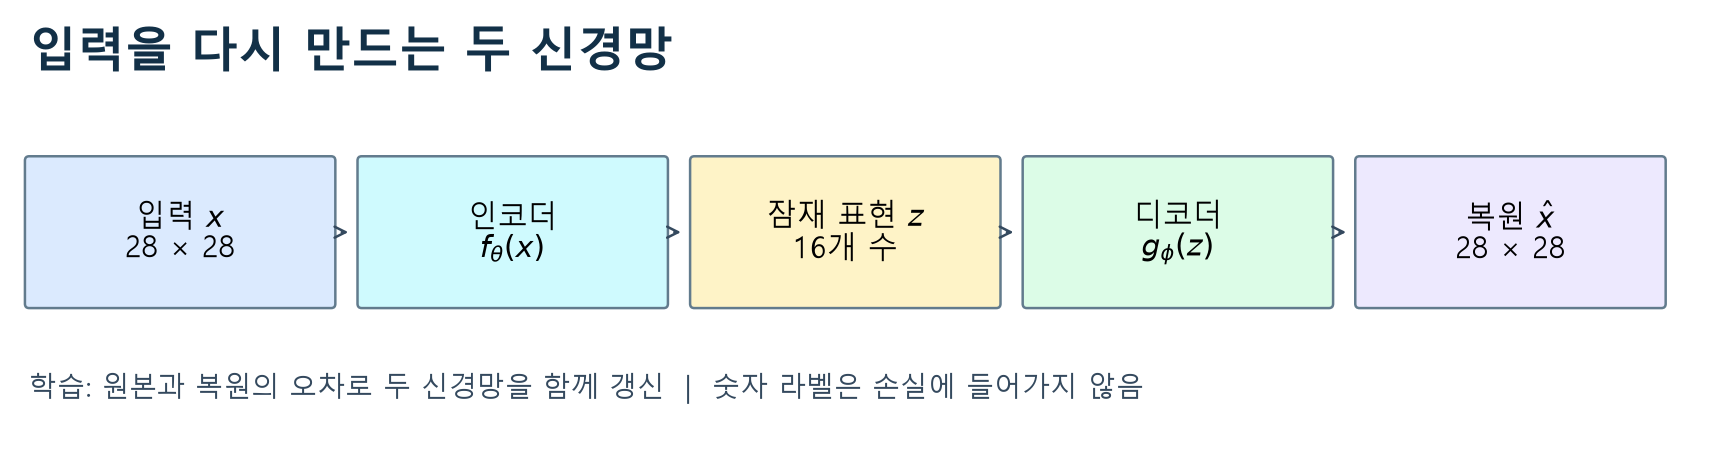
인코더는 $z=f_\theta(x)$, 디코더는 $\hat{x}=g_\phi(z)$입니다.
학습 목표는 숫자 이름이 아니라 원본 픽셀과 복원 픽셀의 차이를 줄이는 것입니다.

처음 쓸 `load_mnist`는 [공통 모듈 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py)
에 있습니다. 인자 기본값: train_size=6000, validation_size=1000, test_size=1000,
seed=1337, offline=False. 반환값은 `MNISTSplit`: train/validation/test 텐서,
test_labels, 각 split의 원본 인덱스, downloads와 cache_dir입니다.
최초 다운로드와 캐시 디렉터리 생성을 수행하며, 이후 체크섬이 맞는 파일을 재사용합니다.
실패하면 원인과 재실행 안내를 출력하고 중단합니다. 가짜 데이터로 바꾸지 않습니다.
입력 픽셀은 uint8 0–255에서 float32 0–1로 바꾸며 shape은 $(N,1,28,28)$입니다.
train과 validation의 인덱스는 원 train 기준, test 인덱스는 별도 원 test 기준입니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/2026-fall-w04a/course/notion/w04a/assets/01-overview.png)


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from luna_genai.autoencoder import (load_mnist, ConvAutoencoder, fit_autoencoder,
    reconstruct, reconstruction_mse, comparison_rows, reconstruction_figure,
    latent_figure, build_autoencoder_app, MNIST_CSS)
torch.set_num_threads(2)
data = load_mnist()
print('새로 받은 파일:', data.downloads or '없음: 검증된 캐시 재사용')
print('캐시:', data.cache_dir)
for name in ('train', 'validation', 'test'):
    values = getattr(data, name)
    print(name, tuple(values.shape), values.dtype, float(values.min()), float(values.max()))
print('train/validation 중복:', len(np.intersect1d(data.train_ids, data.validation_ids)))


### A · 입력과 라벨 읽기
A1. `(128,1,28,28)`의 네 숫자는 무엇을 뜻하나요? 목표·힌트: 배치와 특징 축을 구별하세요.
A2. 숫자 label을 삭제해도 AE 학습이 가능한 이유와, 이 수업에서 label의 용도를 쓰세요.
자가 점검: 이미지가 128장이면 손실에 들어가는 픽셀 수는 `128*1*28*28`개입니다.


## 2. 인코더와 디코더의 차원을 추적한다
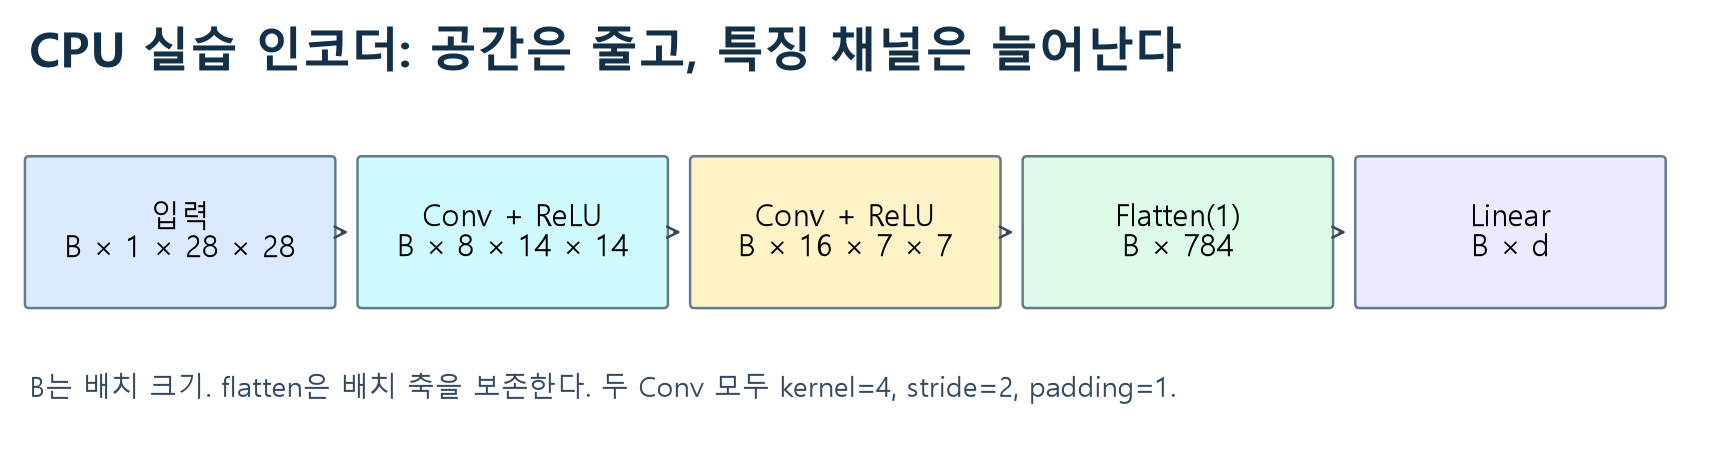
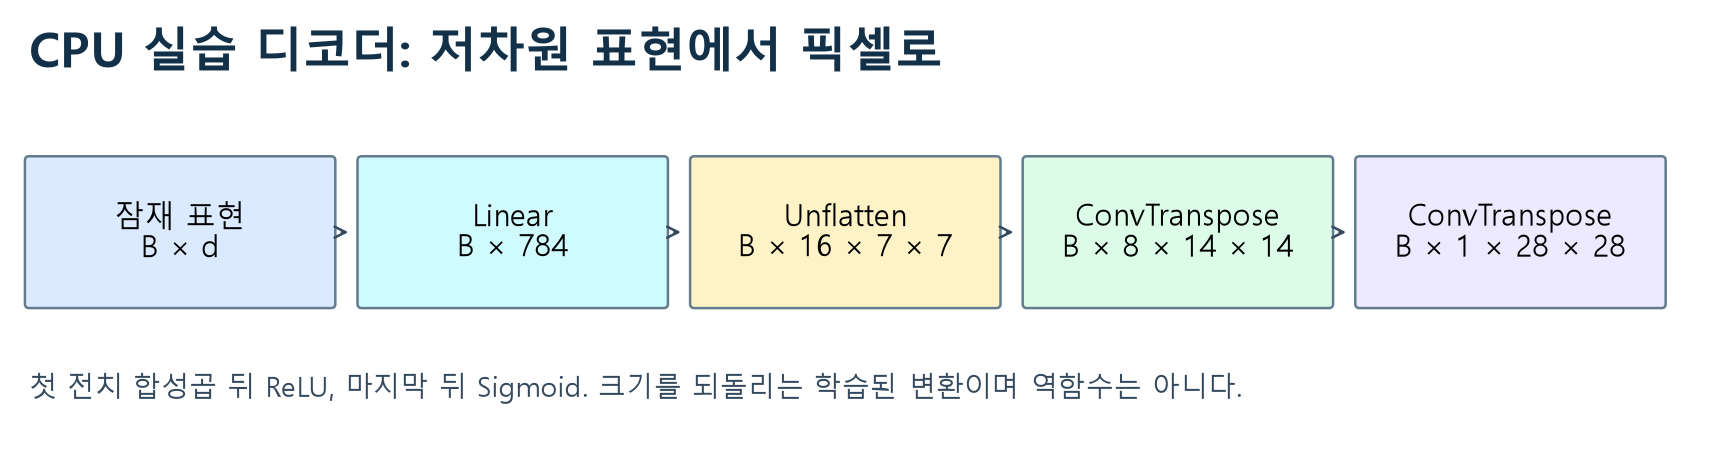
그림은 자체 제작한 작은 모델입니다. 교재의 128→256→512→1024 채널 모델을 그대로 실행한 결과가 아닙니다.

`ConvAutoencoder(latent_dim=16, seed=1337)`은 무작위 모수를 가진 `torch.nn.Module`을 생성합니다.
[정의와 API](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py)
의 `encode(x)`는 `(B,d)`, `decode(z)`와 `forward(x)`는 `(B,1,28,28)`을 반환합니다.
생성자 seed는 torch 난수 상태를 초기화합니다. 생성만으로 다운로드나 학습은 하지 않습니다.
`eval()`은 평가 모드, `inference_mode()`는 미분 기록 생략이며 역할이 다릅니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/2026-fall-w04a/course/notion/w04a/assets/02-encoder.png) · [Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/2026-fall-w04a/course/notion/w04a/assets/03-decoder.png)


In [ ]:
models = {d: ConvAutoencoder(d) for d in (16, 2)}
sample = data.train[:4]
with torch.inference_mode():
    values = sample
    print('input', tuple(values.shape))
    for layer in models[16].encoder:
        values = layer(values)
        print(type(layer).__name__, tuple(values.shape))
    for layer in models[16].decoder:
        values = layer(values)
        print(type(layer).__name__, tuple(values.shape))
print('학습할 모수 수:', {d: sum(p.numel() for p in m.parameters()) for d, m in models.items()})


### B · 배치를 유지하는 빈칸
B1. 특징이 `(4,16,7,7)`일 때 아래 빈칸 두 개를 채우세요.
`flat = features.flatten(start_dim=___)` / `expected_width = 16 * ___ * ___`
B2. `flatten(start_dim=0)`을 쓰면 어떤 문제가 생기나요?
힌트: Linear는 이미지마다 같은 길이의 벡터를 받습니다. 자가 점검: flat의 첫 축은4여야 합니다.


In [ ]:
exercise_start_dim = None  # 여기에 정수를 작성
exercise_width = None      # 여기에 곱셈식을 작성
features = torch.zeros(4, 16, 7, 7)
if exercise_start_dim is not None and exercise_width is not None:
    exercise_flat = features.flatten(start_dim=exercise_start_dim)
    print('내 답의 shape:', tuple(exercise_flat.shape), '예상 폭:', exercise_width)
else:
    print('B 빈칸을 채운 뒤 이 셀만 다시 실행하세요. 다음 실험은 독립 실행 가능합니다.')


## 3. 작은 숫자로 손실을 이해한다
전체 픽셀 평균 제곱 오차는 $L=\frac{1}{BCHW}\sum_{b,c,h,w}(x_{bchw}-\hat{x}_{bchw})^2$입니다.
`torch.nn.functional.mse_loss(prediction, target)`의 기본 reduction은 mean입니다.
두 인자의 shape을 정확히 맞춥니다. 자동 broadcasting에 기대지 않습니다.


In [ ]:
toy_x = torch.tensor([[0., 1.], [.5, .5]])
toy_prediction = torch.tensor([[.2, .8], [.4, .6]])
print('원소별 제곱 오차\n', (toy_prediction - toy_x).square())
print('전체 평균', torch.nn.functional.mse_loss(toy_prediction, toy_x).item())


### C · target과 정규화 디버깅
C1. 같은 두 배열로 계산한 MSE가0.1이라면 어느 연산을 빠뜨렸나요?
C2. `mse_loss(pred, labels)` 대신 target 자리에 무엇을 넣어야 하나요?
C3. 입력을 0–255로 둔 채 출력만 Sigmoid로 제한하면 왜 학습 목표가 맞지 않나요?
목표: 손실의 분모·정답·범위를 구별합니다. 힌트: 원본과 복원의 단위부터 맞추세요.
자가 점검: 위4픽셀의 평균은0과0.1 사이입니다. 실제 입력 범위는 앞의 출력에서 확인합니다.


## 4. 실제 한 단계의 학습
아래 `step_model`은 한 단계 관찰 전용으로, 뒤의16/2차원 비교와 분리되어 있습니다.
`zero_grad`는 이전 gradient 비우기, 순전파는 복원 계산, `backward`는 미분 계산,
`step`은 모수 갱신입니다. 한 배치에서 손실이 항상 줄어든다는 보장은 없습니다.
`Adam(..., lr=0.001)`은 학습률0.001의 optimizer이며 모수와 내부 상태를 갱신합니다.


In [ ]:
step_model = ConvAutoencoder(16)
optimizer = torch.optim.Adam(step_model.parameters(), lr=0.001)
x_batch = data.train[:128]
weights_before = next(step_model.parameters()).detach().clone()
optimizer.zero_grad(set_to_none=True)
prediction = step_model(x_batch)
step_loss = torch.nn.functional.mse_loss(prediction, x_batch)
step_loss.backward()
gradient_norm = float(next(step_model.parameters()).grad.norm())
optimizer.step()
weight_change = float((next(step_model.parameters()).detach()-weights_before).abs().sum())
print('갱신 전 손실:', float(step_loss.detach()), 'gradient norm:', gradient_norm, '모수 변화 합:', weight_change)


### D · 코드의 역할 설명
D1. `backward()`까지만 실행하고 `optimizer.step()`을 빼면 무엇이 바뀌고 무엇이 그대로인가요?
D2. `model.eval()`만 호출하면 gradient 기록도 꺼지나요?
힌트: 모수 값·gradient·모듈 동작 모드를 각각 구별하세요. 자가 점검: 위 모수 변화 합은양수입니다.


## 5. 고정한 조건으로 두 모델을 학습한다
`reconstruction_mse(model, images)`는 eval/inference_mode에서 전체 픽셀 평균 float를 반환합니다.
`fit_autoencoder(model, train, validation, epochs=5, batch_size=128, lr=0.001, seed=1337, threads=2)`는
모델을 실제 갱신하고 epoch별 train_mse/val_mse/seconds 딕셔너리 목록을 반환합니다.
[정의·부작용](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py): CPU thread수 변경,
Adam 학습, epoch마다 validation 평가. test와 숫자 라벨을 받지 않습니다.
재호출은 초기화가 아니라 이어서 학습입니다. 처음과 비교하려면 모델 생성 셀부터 다시 실행합니다.
다섯 epoch은 사전에 정한 수업 설정입니다. test 결과를 보고 epoch을 고르지 않습니다.
train_mse는 갱신 중 배치 손실 평균, val_mse는 epoch 끝 모델의 평가이므로 완전히 같은 시점이 아닙니다.


In [ ]:
before_mse = {d: reconstruction_mse(m, data.test) for d, m in models.items()}
histories = {}
for d, model in models.items():
    histories[d] = fit_autoencoder(model, data.train, data.validation)
    print('잠재 차원', d)
    display(pd.DataFrame(histories[d]).round(5))


## 6. 같은 미사용 이미지로 평가한다
`comparison_rows(models, data)`는 학습 평균 이미지 기준선과 각 모델의 test MSE/모수 수 목록을 반환합니다.
평균 이미지는 train에서 픽셀별 평균을 내고 모든 test에 같은 이미지를 예측합니다.
`reconstruction_figure(models, data, count=8)`는 test의 첫8장을 고정 순서로 그린 Figure를 반환합니다.
[함수 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py).
둘 다 학습하지 않고, 함수가 만든 그림은 호출자가 표시/저장/닫습니다. 픽셀 범위는 항상0–1입니다.


In [ ]:
results = pd.DataFrame(comparison_rows(models, data))
display(results)
print('학습 전 test MSE:', before_mse)
fig = reconstruction_figure(models, data)
display(fig)
plt.close(fig)


### E · 공정한 비교와 해석
E1. 내 실행에서16차원/2차원/평균 기준선의 MSE를 기록하고, 흐려진 획의 예를 하나 적으세요.
E2.16차원의 오차가 더 작았다면 모든 데이터·학습 조건에서 항상 그렇다고 결론 내릴 수 있나요?
E3.784/16=49를 그대로 실제 파일의 바이트 압축률이라고 말할 수 있나요?
목표: 실측과 일반화를 구별합니다. 힌트: 표현 dtype, 모델 모수, 학습 조건을 생각하세요.
자가 점검: 비교할 때 같은 test 인덱스·표본 수·손실 분모를 썼는지 확인합니다.


## 7. 잠재 공간은 학습된 좌표다
`latent_figure(model, images, labels)`는 d=2인 모델만 받아2차원 산점도 Figure를 반환합니다.
[정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py).
labels는 각 점의 색에만 쓰며, 인코더 학습에 들어가지 않습니다. 축에 미리 정한 의미는 없습니다.
test 산점도는 마지막 관찰용입니다. 아래 좌표 탐색 범위는 validation의5–95% 분위수에서 정합니다.


In [ ]:
fig = latent_figure(models[2], data.test, data.test_labels)
display(fig)
plt.close(fig)
models[2].eval()
with torch.inference_mode():
    validation_codes = models[2].encode(data.validation)
    low = torch.quantile(validation_codes, 0.05, dim=0)
    high = torch.quantile(validation_codes, 0.95, dim=0)
    random_codes = low + torch.rand((8, 2), generator=torch.Generator().manual_seed(1337)) * (high-low)
    random_images = models[2].decode(random_codes)
fig, axes = plt.subplots(1, 8, figsize=(10, 2))
for ax, pixels in zip(axes, random_images):
    ax.imshow(pixels[0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
display(fig)
plt.close(fig)
print('임의 좌표를 뽑은 사각형 범위:', low.tolist(), high.tolist())


### F · 복원과 임의 생성 구별
F1. 겹치는 색의 점이 있으면 라벨 분류에 실패한 것인가요?
F2. 사각형 안의 임의 좌표가 실제 이미지의 인코딩 근처에 있다는 보장이 있나요?
F3. 좋은 복원 손실만으로 좋은 임의 샘플 생성이 보장되지 않는 이유를 두 문장으로 설명하세요.
힌트: 학습이 디코더에게 어떤 z를 보여 주었는지 생각하세요. 자가 점검: AE 손실에는
모든 잠재 좌표에서 숫자 모양을 만들라는 조건이 없습니다.


## 8. 마지막 웹 앱: 기존 기능에 좌표 탐색을 조립한다
`build_autoencoder_app(models, images)`는 `(app, callback)`을 반환합니다.
[정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w04a/src/luna_genai/autoencoder.py).
제공 기능은 테스트 이미지 번호와 잠재 차원 선택 → 원본/복원/오차입니다. 다운로드나 학습·서버 시작은 없습니다.
`callback(index, dimension)`의 반환은 uint8원본, uint8복원, 설명문자열 순서입니다.
먼저 함수를 직접 호출하여 입출력을 확인한 뒤 화면에서 같은 동작을 확인합니다.


In [ ]:
app, reconstruction_ui = build_autoencoder_app(models, data.test)
original_ui, restored_ui, report_ui = reconstruction_ui(0, 16)
print(original_ui.shape, restored_ui.shape, report_ui)


`MNIST_CSS`는 원래28×28 픽셀을 화면에서224×224로 확대 표시합니다. 데이터·MSE는 바꾸지 않습니다.
`launch`가 실행 서버를 시작합니다. `share=False`는 로컬 확인용 기본값입니다.
Colab에서 외부 링크가 필요하면 아래 SHARE를 True로 바꿉니다. 공유 링크는 런타임에 의존하고
런타임 종료 후 계속 유지되는 배포 사이트가 아닙니다. 개인 정보는 입력하지 않습니다.
이 셀을 다시 실행할 때는 먼저 `app.close()`로 기존 서버를 닫습니다.


In [ ]:
SHARE = False
app.launch(share=SHARE, prevent_thread_lock=True, quiet=True, css=MNIST_CSS)


### G · 좌표 탐색 UI 연결하기
G1. 아래 `decode_for_ui(a,b)`의 빈칸을 완성하세요. 입력 두 실수 → `(1,2)` float32 텐서 →
2차원 모델 decode → `(28,28)` uint8 이미지를 반환합니다.
G2. `draw.click`에 함수·입력 두 개·출력 하나를 순서대로 연결하세요.
힌트: `torch.tensor`, `torch.inference_mode`, `models[2].decode`, `numpy`를 사용합니다.
자가 점검: 같은 좌표를 두 번 주면 같은 그림, 좌표를 바꾸면 대체로 다른 그림입니다.
G3. 이미지와 함께 “이 좌표는 실제 입력의 인코딩이 아닐 수 있음”이라는 안내를 UI에 추가하세요.
학생용 초안은 미완성이어도 import/기본 앱 실행을 막지 않습니다. 완성했을 때만 `READY=True`로 바꿉니다.


In [ ]:
import gradio as gr
READY = False
def decode_for_ui(a, b):
    # TODO: (1,2) float32 텐서 → eval/inference_mode → decode → uint8 2D 배열
    return None

with gr.Blocks() as latent_app:
    gr.Markdown('# 내가 만드는 잠재 좌표 탐색기')
    a = gr.Slider(float(low[0]), float(high[0]), value=float((low[0]+high[0])/2), label='z1')
    b = gr.Slider(float(low[1]), float(high[1]), value=float((low[1]+high[1])/2), label='z2')
    draw = gr.Button('좌표에서 복원', interactive=READY)
    latent_image = gr.Image(label='디코더 출력', image_mode='L', format='png', height=280, interactive=False, elem_classes='mnist-pixels')
    # TODO: draw.click(fn=..., inputs=[..., ...], outputs=...)
if READY:
    latent_app.launch(share=SHARE, prevent_thread_lock=True, quiet=True, css=MNIST_CSS)
else:
    print('G1/G2/G3을 작성한 뒤 READY=True로 바꾸세요. 제공된 복원 앱은 이미 사용 가능합니다.')


## 9. 실행 결과의 불변량 확인
다음 검사는 실제 데이터·모델·callback의 기본 동작을 확인합니다. 웹 브라우저 버튼 조작이나
모든 Colab 환경의 성공을 대신하지 않습니다. seed를 고정해도 장치·라이브러리에 따라 수치는 달라집니다.


In [ ]:
assert data.train.shape == (6000, 1, 28, 28) and data.test.shape == (1000, 1, 28, 28)
assert not np.intersect1d(data.train_ids, data.validation_ids).size
assert gradient_norm > 0 and weight_change > 0
baseline_mse = float(results.iloc[0]['test_mse'])
for d, model in models.items():
    y = reconstruct(model, data.test[:11])
    assert y.shape == data.test[:11].shape and torch.isfinite(y).all()
    assert 0 <= y.min() <= y.max() <= 1
    independent_mse = float(np.mean((y.numpy()-data.test[:11].numpy())**2))
    assert abs(independent_mse-reconstruction_mse(model, data.test[:11])) < 1e-7
    current_mse = reconstruction_mse(model, data.test)
    assert current_mse < before_mse[d]
    if d == 16:
        assert current_mse < baseline_mse
    assert len(histories[d]) == 5 and np.isfinite(pd.DataFrame(histories[d]).to_numpy()).all()
assert original_ui.dtype == np.uint8 and restored_ui.shape == (28,28) and 'MSE=' in report_ui
cached = load_mnist(offline=True)
assert not cached.downloads and torch.equal(cached.test, data.test)
print('실제 학습·shape·손실 검산·기준선·callback·오프라인 캐시 검사 통과')


### H · 출구 문장
“AE는 입력의 ___를 학습하여 ___하고, 학습되지 않은 잠재 좌표에서의 ___는 보장하지 않는다.”
빈칸을 자기 말로 채우세요. 힌트: 표현·복원·임의 생성의 차이를 한 문장으로 연결합니다.


마친 뒤 아래 RUN_CLEANUP을 True로 바꾸면 실행 중 앱을 닫습니다.
Colab 런타임을 종료해도 메모리의 모델과 공유 서버가 사라집니다. 실험 기록은 Drive에 저장하세요.


In [ ]:
RUN_CLEANUP = False
if RUN_CLEANUP:
    app.close()
    if READY:
        latent_app.close()
